In [51]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from catboost import CatBoostClassifier

In [52]:
np.random.seed(42)
n_samples = 1000

In [53]:
numeric_data = {
    'age': np.random.normal(35, 10, n_samples),
    'income': np.random.normal(60000, 20000, n_samples),
    'browsing_time': np.random.normal(30, 15, n_samples)
}

# Categorical features
education_levels = ['High School', 'Bachelor', 'Master', 'PhD']
occupations = ['Student', 'Professional', 'Business', 'Retired']
shopping_categories = ['Electronics', 'Clothing', 'Home & Garden', 'Books']

categorical_data = {
    'education': np.random.choice(education_levels, n_samples),
    'occupation': np.random.choice(occupations, n_samples),
    'preferred_category': np.random.choice(shopping_categories, n_samples)
}

In [54]:
df = pd.DataFrame({**numeric_data, **categorical_data})

le_dict = {}
for col in ['education', 'occupation', 'preferred_category']:
    le_dict[col] = LabelEncoder()
    df[col] = le_dict[col].fit_transform(df[col])

df['will_purchase'] = (
    (df['age'] > 30) & 
    (df['income'] > 50000) & 
    (df['browsing_time'] > 20) & 
    (df['education'] >= 2) &  # Higher education levels
    ((df['occupation'] == 1) | (df['occupation'] == 2))  # Professionals or Business
).astype(int)

X = df.drop('will_purchase', axis=1)
y = df['will_purchase']

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [56]:
DecisionTreeClassifier?

In [57]:
y_pred = dt.predict(X_test)

# Print model performance
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.91

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.90      0.95       178
           1       0.55      1.00      0.71        22

    accuracy                           0.91       200
   macro avg       0.78      0.95      0.83       200
weighted avg       0.95      0.91      0.92       200



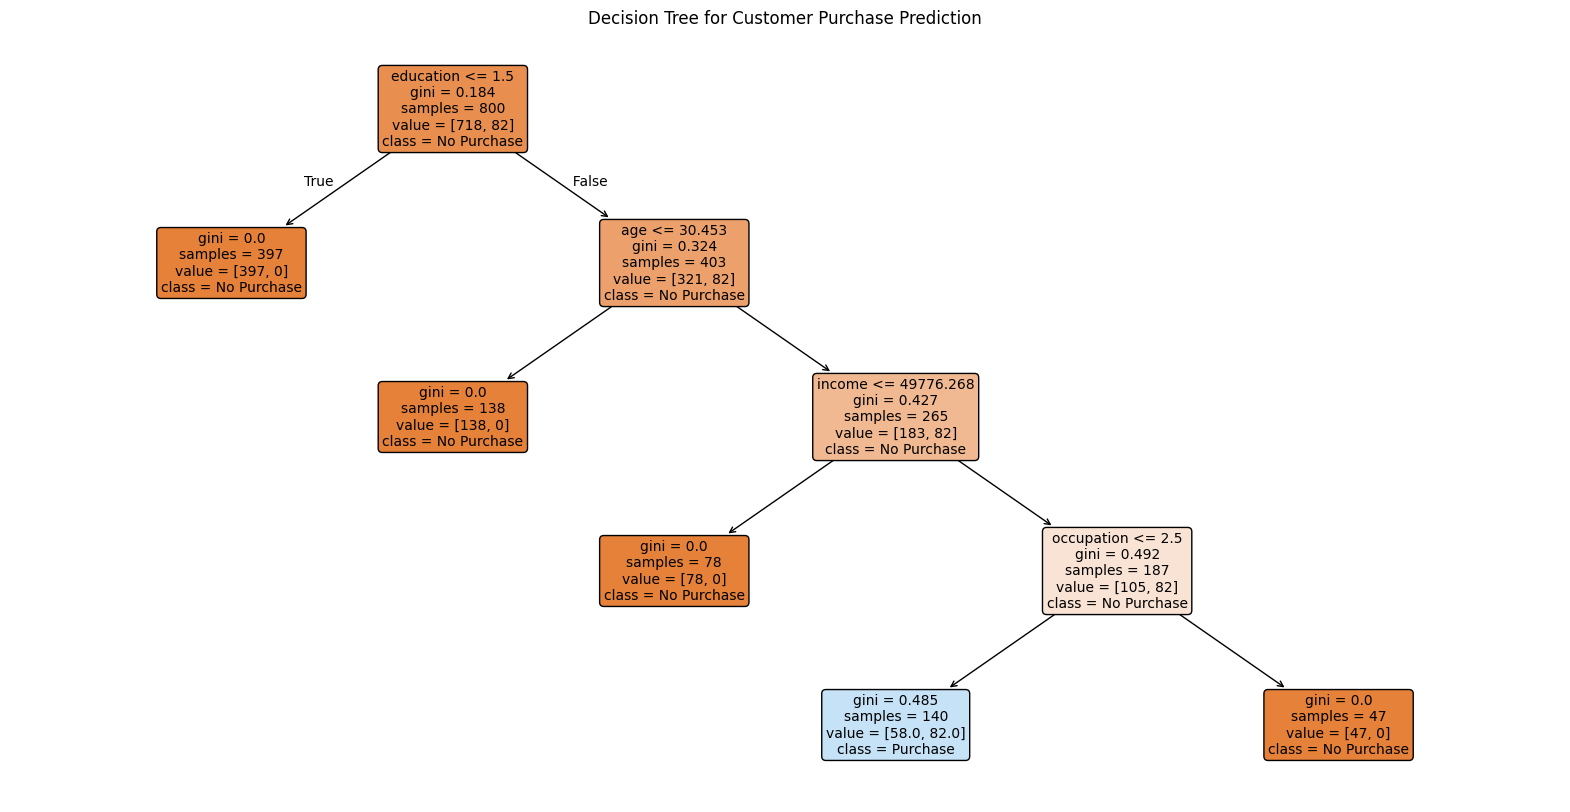

In [58]:
plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=X.columns, class_names=['No Purchase', 'Purchase'], 
          filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree for Customer Purchase Prediction")
plt.show()

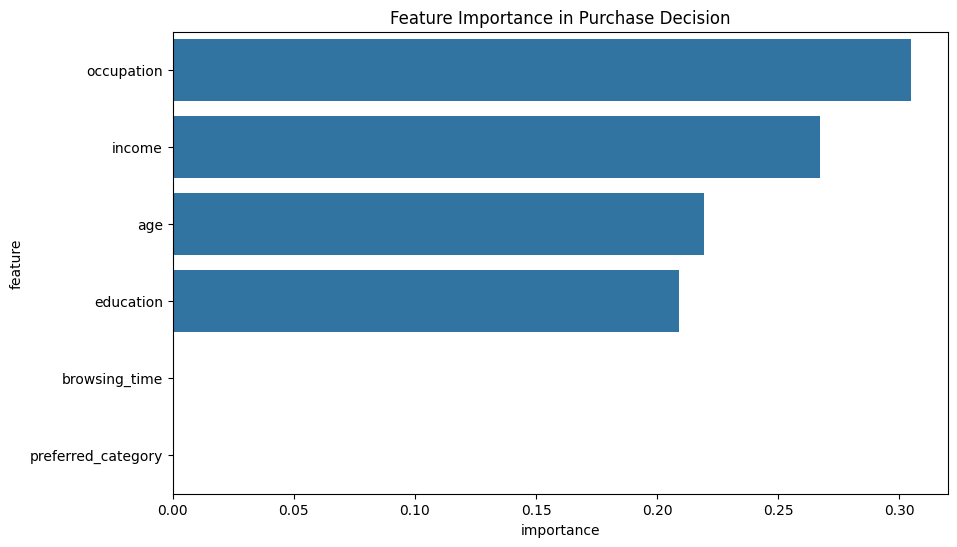

In [59]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': dt.feature_importances_
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title("Feature Importance in Purchase Decision")
plt.show()


In [60]:
new_customers = pd.DataFrame({
    'age': [25, 40, 35],
    'income': [45000, 80000, 60000],
    'browsing_time': [15, 45, 25],
    'education': le_dict['education'].transform(['Bachelor', 'Master', 'PhD']),
    'occupation': le_dict['occupation'].transform(['Student', 'Professional', 'Business']),
    'preferred_category': le_dict['preferred_category'].transform(['Electronics', 'Books', 'Clothing'])
})

predictions = dt.predict(new_customers)
new_customers['predicted_purchase'] = predictions

# Decode categorical variables for display
for col in ['education', 'occupation', 'preferred_category']:
    new_customers[col] = le_dict[col].inverse_transform(new_customers[col])

print("\nPredictions for new customers:")
print(new_customers)


Predictions for new customers:
   age  income  browsing_time education    occupation preferred_category  \
0   25   45000             15  Bachelor       Student        Electronics   
1   40   80000             45    Master  Professional              Books   
2   35   60000             25       PhD      Business           Clothing   

   predicted_purchase  
0                   0  
1                   1  
2                   1  


# Random Forest

In [61]:
rf = RandomForestClassifier(n_estimators=10, max_depth=4, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [62]:
print("\nRandom Forest Performance:")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))


Random Forest Performance:
Accuracy: 0.925

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       178
           1       1.00      0.32      0.48        22

    accuracy                           0.93       200
   macro avg       0.96      0.66      0.72       200
weighted avg       0.93      0.93      0.91       200



# Bagging

In [63]:
BaggingClassifier?

In [64]:
bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=4),
    n_estimators=10,
    max_samples=0.8,
    max_features=0.8,
    random_state=42
)
bag.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(max_depth=4),
                  max_features=0.8, max_samples=0.8, random_state=42)

In [65]:
bag_pred = bag.predict(X_test)

In [66]:
print("\nBagging Performance:")
print("Accuracy:", accuracy_score(y_test, bag_pred))
print("\nClassification Report:")
print(classification_report(y_test, bag_pred))


Bagging Performance:
Accuracy: 0.935

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96       178
           1       1.00      0.41      0.58        22

    accuracy                           0.94       200
   macro avg       0.97      0.70      0.77       200
weighted avg       0.94      0.94      0.92       200



# AdaBoost

In [67]:
AdaBoostClassifier?

In [75]:
adaboost = AdaBoostClassifier(
        DecisionTreeClassifier(max_depth=4),
        n_estimators=10,
        random_state=42
    )

adaboost.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=4),
                   n_estimators=10, random_state=42)

In [76]:
adaboost_pred = adaboost.predict(X_test)

In [77]:
print("\nAdaBoost Performance:")
print("Accuracy:", accuracy_score(y_test, adaboost_pred))
print("\nClassification Report:")
print(classification_report(y_test, adaboost_pred))


AdaBoost Performance:
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       178
           1       1.00      1.00      1.00        22

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [71]:
adaboost_pred = adaboost.predict(X_train)
print("\nAdaBoost Performance:")
print("Accuracy:", accuracy_score(y_train, adaboost_pred))
print("\nClassification Report:")
print(classification_report(y_train, adaboost_pred))


AdaBoost Performance:
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       718
           1       1.00      1.00      1.00        82

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800



# Catboost

In [78]:
catboost = CatBoostClassifier(
        iterations=100,
        depth=4,
        learning_rate=0.1,
        random_seed=42,
        verbose=False,
        cat_features=['education', 'occupation', 'preferred_category']
    )


catboost.fit(X_train, y_train)


In [79]:
catboost_pred = catboost.predict(X_test)

In [80]:
print("\nCatBoost Performance:")
print("Accuracy:", accuracy_score(y_test, catboost_pred))
print("\nClassification Report:")
print(classification_report(y_test, catboost_pred))


CatBoost Performance:
Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       178
           1       1.00      1.00      1.00        22

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



# Stacking

In [82]:
base_models = [
    ('knn', KNeighborsClassifier(n_neighbors=5)),
#     ('lr', LogisticRegression(random_state=42)),
    ('dt', DecisionTreeClassifier(max_depth=4, random_state=42))
]

meta_model = KNeighborsClassifier(n_neighbors=3)

stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
)


In [83]:
models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
#     'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=42),
    'Stacking': stacking
}

In [84]:
results = {}
predictions = {}
for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    
    # Store results
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'report': classification_report(y_test, y_pred, output_dict=True)
    }

In [85]:
print("\nModel Performance Comparison:")
for name in models.keys():
    print(f"\n{name}:")
    print(f"Accuracy: {results[name]['accuracy']:.4f}")
    print("\nClassification Report:")
    print(pd.DataFrame(results[name]['report']).transpose())


Model Performance Comparison:

KNN:
Accuracy: 0.8850

Classification Report:
              precision    recall  f1-score  support
0              0.893401  0.988764  0.938667  178.000
1              0.333333  0.045455  0.080000   22.000
accuracy       0.885000  0.885000  0.885000    0.885
macro avg      0.613367  0.517109  0.509333  200.000
weighted avg   0.831794  0.885000  0.844213  200.000

Decision Tree:
Accuracy: 0.9100

Classification Report:
              precision    recall  f1-score  support
0                1.0000  0.898876  0.946746   178.00
1                0.5500  1.000000  0.709677    22.00
accuracy         0.9100  0.910000  0.910000     0.91
macro avg        0.7750  0.949438  0.828211   200.00
weighted avg     0.9505  0.910000  0.920668   200.00

Stacking:
Accuracy: 0.8800

Classification Report:
              precision    recall  f1-score  support
0              0.947674  0.915730  0.931429   178.00
1              0.464286  0.590909  0.520000    22.00
accuracy       0.8